In [ ]:
# 1. Install Korean fonts
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import os
print("Font installation is complete. Restarting the runtime.")
os.kill(os.getpid(), 9)

# after run this cell, run the next cell.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and direc

In [13]:
import os
import json
import glob
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re

## advance data processing

We went through the following process of preprocessing the original data in advance. From the code below, data analysis is performed using the csv file generated through this process.


```
# import zipfile
import json
import glob
import pandas as pd
from google.colab import files
from pykospacing import Spacing
# --- 1. Settings: Decryption Table (Code Mapping) ---
instrument_map = {
    'SP01': '가야금', 'SP02': '거문고', 'SP03': '비파', 'SP04': '철현금', 'SR01': '해금', 'SR02': '아쟁',
    'WN01': '대금', 'WN02': '소금', 'WN03': '단소', 'WR01': '피리', 'WR02': '태평소', 'WR03': '생황',
    'PN01': '장구', 'PN02': '꽹과리', 'PN03': '북', 'PN04': '징', 'VF01': '여성성악', 'VM02': '남성성악'
}

mode_map = {
    'MF01': '평조', 'MF02': '풍류평조', 'MG09': '계면조', 'MG10': '풍류계면조',
    'MG13': '육자배기조', 'MG12': '수심가조', 'MF08': '장조', 'MG18': '단조'
}

beat_map = {
    'DQ0404': '자진모리', 'DQ0405': '굿거리', 'QN0401': '휘모리', 'QN1202': '중모리', 'DQ0603': '진양조'
}

# ==========================================
#2. Run data integration and spelling (spacing) correction
# ==========================================

spacing = Spacing()
extract_folder = "./gugak_extracted"

# unzip
zip_files = glob.glob('*.zip')
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)
    for zip_file in zip_files:
        try:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(extract_folder)
        except: pass

# Find JSON file
json_files = glob.glob(f'{extract_folder}/**/*.json', recursive=True)
print(f"File to be analyzed: {len(json_files)}")

results = []

for idx, filepath in enumerate(json_files):
    # Display progress (print every 100 files as there are many)
    if idx % 100 == 0:
        print(f"   Running... ({idx}/{len(json_files)})")

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Basic information
        info = data.get('music_source_info', {})
        annot = data.get('annotation_data_info', {})
        type_info = data.get('music_type_info', {})

        filename = os.path.basename(filepath)
        title = info.get('music_nm_kor', '')
        player = type_info.get('main_instr_player', '')
        duration = info.get('play_time', 0)

        # Soul Analysis
        sigimsae_count = len(annot.get('single_tonguing_cd', []))
        soul_score = round(sigimsae_count / duration, 2) if duration > 0 else 0

        # Lyrics processing (AI spacing applied)
        lyrics_list = annot.get('lyrics', [])
        combined_lyrics = ""

        if lyrics_list:
            raw_string = ""
            for item in lyrics_list:
                char = item.get('annotation_code', '')
                if char != '-':
                    raw_string += char
            if len(raw_string) > 1:
                combined_lyrics = spacing(raw_string)
            else:
                combined_lyrics = raw_string

            data_type = "Vocal"
        else:
            data_type = "Instrumental"

        results.append({
            "filename": filename,
            "type": data_type,
            "title": title,
            "artist": player,
            "techniques": sigimsae_count,
            "Soul Score": soul_score,
            "lyrics": combined_lyrics,
            "rhythm": beat_map.get(annot.get('gukak_beat_cd'), ''),
            "instrument": instrument_map.get(type_info.get('instrument_cd'), '')
        })

    except Exception as e:
        print(f"⚠️ Error {filepath}: {e}")

# save
if results:
    df = pd.DataFrame(results)
    output_filename = "국악_통합데이터_10개압축분.csv" #gukak Data 10 Compressed Volumes
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"\n Completed '{output_filename}' Downloading start")
    files.download(output_filename)
else:
    print("No data.")
```



In [14]:
df = pd.read_csv("국악_통합데이터_10개압축분.csv")

In [15]:
df.head() # check whether data is accurately uploaded.

,filename,type,title,artist,techniques,Soul Score,lyrics,rhythm,instrument
0,AP_F05_08452.json,Instrumental,웃다리풍물,NaN,0,0.00,NaN,NaN,꽹과리
1,AP_F08_01788.json,Vocal,판소리 춘향가,이주은,2,0.33,방자분 부 듣고 춘향부르러 건너간다,자진모리,여성성악
2,BP_FS2_02878.json,Instrumental,신시나위1-거리,NaN,3,0.36,NaN,굿거리,피리
3,AP_F05_07932.json,Instrumental,웃다리풍물 (지금풍류),NaN,0,0.00,NaN,휘모리,꽹과리
4,AP_E01_03812.json,Instrumental,영산회상 타령(지금풍류),황진아,9,0.39,NaN,NaN,거문고


In [16]:
df.info() # check data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9961 entries, 0 to 9960
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    9961 non-null   object 
 1   type        9961 non-null   object 
 2   title       9961 non-null   object 
 3   artist      7970 non-null   object 
 4   techniques  9961 non-null   int64  
 5   Soul Score  9961 non-null   float64
 6   lyrics      2721 non-null   object 
 7   rhythm      3263 non-null   object 
 8   instrument  9747 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 700.5+ KB


Data loading...
✅ 'final_melon_chart_analysis.csv' Load success (encoding: utf-8)
✅ '국악_통합데이터_10개압축분.csv' Load success (encoding: utf-8)

Analyzing Gugak Data...
   Composite Weighted Average Emotion Score (Instrument & Beat Reflected): 0.3471
Analyzing Melon...

🏆Top 3 singers most similar to gukak after applying composite weighting:
1place: 유승우 (score: 0.3474, difference: 0.00021)
2place: Jennifer Lopez (score: 0.3477, difference: 0.00052)
3place: 김형중 (score: 0.3464, difference: 0.00078)


/tmp/ipython-input-3826142890.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gugak_valid['meta_weight'] = gugak_valid.apply(calculate_meta_weight, axis=1)
/tmp/ipython-input-3826142890.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gugak_valid['composite_weight'] = gugak_valid['Soul Score'] * gugak_valid['meta_weight']


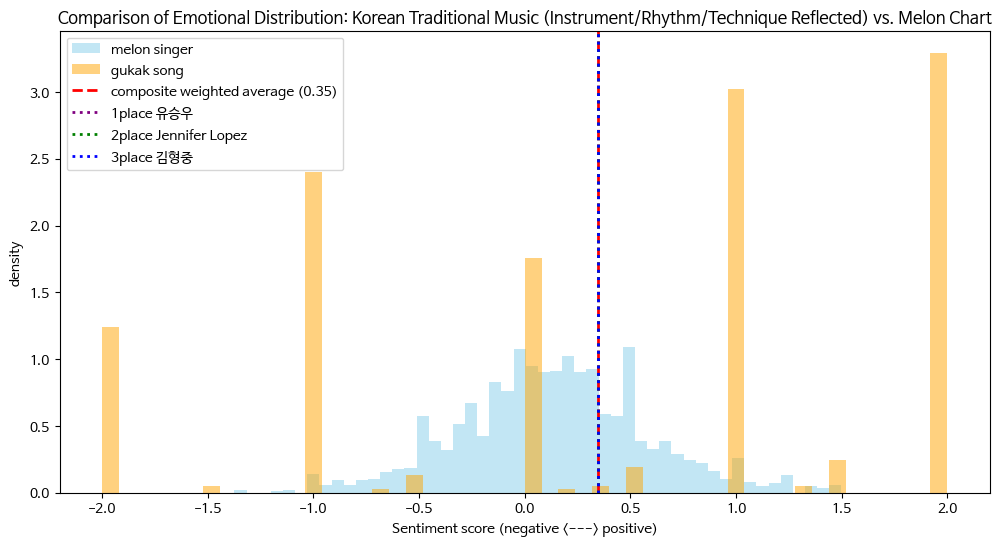

In [17]:
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

def load_csv_robust(filename):
    if not os.path.exists(filename):
        print(f"Error: File '{filename}' does not exist. Please check your upload.")
        return None

    encodings = ['utf-8', 'cp949', 'euc-kr', 'latin1']
    for enc in encodings:
        try:
            df = pd.read_csv(filename, encoding=enc)
            print(f"✅ '{filename}' Load success (encoding: {enc})")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            # print(f"'{filename}' Unknown error while reading: {e}")
            return None

    print(f" '{filename}'Could not read. The file is corrupted or has an unsupported encoding.")
    return None

# --- 3. [Added] Instrument and rhythm inference/weight function definition ---

def calculate_meta_weight(row):
    """ Calculate instrument/beat meta weights (W_meta) based on the song title (Title). """
    title = str(row['title'])

    #1. Instrument/Rhythm Weight Map
    # (High Weight: 1.5, Medium Weight: 1.2, Default: 1.0)

    # sad/mournful instruments and rhythms (Ajaeng, Haegeum, Jinyangjo)
    if any(x in title for x in ['아쟁', '해금', '진양조', '산조']):
        return 1.5

    # Exciting/grand instruments and rhythms (Taepyeongso, Piri, Hwimori, Gutgeori)
    if any(x in title for x in ['태평소', '꽹과리', '풍물', '사물놀이', '휘모리', '굿거리']):
        return 1.5

    # 2. Common instruments (gayageum, daegeum, etc.)
    if any(x in title for x in ['가야금', '대금', '거문고', '시조', '가곡']):
        return 1.2

    return 1.0 # 기본 가중치


# --- 4. Data Loading and Analysis ---
print("Data loading...")
melon_df = load_csv_robust('final_melon_chart_analysis.csv')
gugak_df = load_csv_robust('국악_통합데이터_10개압축분.csv')

# Emotion dictionary
try:
    with open('SentiWord_info.json', 'r', encoding='utf-8') as f:
        senti_data = json.load(f)
except Exception as e:
    print(f"Sentiment preload failed: {e}")
    senti_data = []


if melon_df is None or gugak_df is None or not senti_data:
    print("\n Analysis aborted due to failure to load required files.")
else:
    # --- 5. Sentiment analysis and weighting of gukak data ---
    senti_dict = {entry['word']: int(entry['polarity']) for entry in senti_data}

    def calc_sentiment(text):
        if not isinstance(text, str): return None
        text = text.replace('\n', ' ')
        tokens = text.split()
        score_sum = 0
        match_count = 0
        for token in tokens:
            if token in senti_dict:
                score_sum += senti_dict[token]
                match_count += 1
                continue
            clean_token = re.sub(r'[^\w]', '', token)
            if clean_token and clean_token in senti_dict:
                score_sum += senti_dict[clean_token]
                match_count += 1
        return score_sum / match_count if match_count > 0 else None

    print("\nAnalyzing Gugak Data...")
    gugak_lyrics = gugak_df[gugak_df['lyrics'].notna()].copy()
    gugak_lyrics['sentiment'] = gugak_lyrics['lyrics'].apply(calc_sentiment)

    # Filter valid data
    gugak_valid = gugak_lyrics.dropna(subset=['sentiment', 'Soul Score'])

    # 1. Calculating and applying meta-weights (instrument/beat)
    gugak_valid['meta_weight'] = gugak_valid.apply(calculate_meta_weight, axis=1)

    # 2. Create composite weights (Composite Weight)
    # W_composite = W_technique (Soul Score) * W_meta (Instrument/Beat)
    gugak_valid['composite_weight'] = gugak_valid['Soul Score'] * gugak_valid['meta_weight']

    # Calculating weighted averages using composite weights
    if gugak_valid['composite_weight'].sum() == 0:
        weighted_gugak_avg = gugak_valid['sentiment'].mean()
    else:
        weighted_gugak_avg = np.average(gugak_valid['sentiment'], weights=gugak_valid['composite_weight'])

    print(f"   Composite Weighted Average Emotion Score (Instrument & Beat Reflected): {weighted_gugak_avg:.4f}")

    # --- 6. Melon Data Analysis and Matching ---
    print("Analyzing Melon...")
    if 'Combined_Avg_Polarity' in melon_df.columns:
        melon_df['sentiment'] = melon_df['Combined_Avg_Polarity']
    else:
        melon_df['sentiment'] = melon_df['가사'].apply(calc_sentiment)

    # Average by singer
    artist_sentiment = melon_df.groupby('artist')['sentiment'].mean()

    # --- 7. Similarity matching (Top 3) ---
    artist_diff = (artist_sentiment - weighted_gugak_avg).abs()
    top_3 = artist_diff.sort_values().head(3)

    print("\n🏆Top 3 singers most similar to gukak after applying composite weighting:")
    for i, (artist, diff) in enumerate(top_3.items()):
        score = artist_sentiment[artist]
        print(f"{i+1}place: {artist} (score: {score:.4f}, difference: {diff:.5f})")

    # --- 8. EDA ---
    plt.figure(figsize=(12, 6))
    plt.hist(artist_sentiment, bins=50, alpha=0.5, label='melon singer', color='skyblue', density=True)
    plt.hist(gugak_valid['sentiment'], bins=50, alpha=0.5, label='gukak song', color='orange', density=True)
    plt.axvline(weighted_gugak_avg, color='red', linestyle='dashed', linewidth=2, label=f'composite weighted average ({weighted_gugak_avg:.2f})')

    colors = ['purple', 'green', 'blue']
    for i, artist in enumerate(top_3.index):
        score = artist_sentiment[artist]
        plt.axvline(score, color=colors[i], linestyle='dotted', linewidth=2, label=f'{i+1}place {artist}')

    plt.title('Comparison of Emotional Distribution: Korean Traditional Music (Instrument/Rhythm/Technique Reflected) vs. Melon Chart')
    plt.xlabel('Sentiment score (negative <---> positive)')
    plt.ylabel('density')
    plt.legend()
    plt.show()

In [20]:
melon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25876 entries, 0 to 25875
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   song_name              25876 non-null  object 
 1   artist                 25876 non-null  object 
 2   genre                  25528 non-null  object 
 3   lyrics                 25236 non-null  object 
 4   year                   25876 non-null  int64  
 5   month                  25876 non-null  int64  
 6   rank                   25876 non-null  int64  
 7   Korean_Avg_Polarity    25236 non-null  float64
 8   English_Avg_Polarity   25236 non-null  float64
 9   Is_Korean_Song         25876 non-null  bool   
 10  Lexical_Diversity      25236 non-null  float64
 11  Combined_Avg_Polarity  25236 non-null  float64
 12  sentiment              25236 non-null  float64
dtypes: bool(1), float64(5), int64(3), object(4)
memory usage: 2.4+ MB


In [18]:
# --- 1. Settings: Already obtained national music standard score and target singer ---
TARGET_GUGAK_SCORE = 0.3471
TARGET_ARTISTS = ['유승우', 'Jennifer Lopez', '김형중']

# --- 2. Loading Melon Data ---
filename = 'final_melon_chart_analysis.csv'
if os.path.exists(filename):
    try:
        df = pd.read_csv(filename, encoding='utf-8')
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(filename, encoding='cp949')
        except:
            df = pd.read_csv(filename, encoding='euc-kr')


else:
    print(" 'final_melon_chart_analysis.csv' no file")
    df = pd.DataFrame()


if not df.empty:
    print(f"\nAnalysis Criteria Score (Korean Traditional Music Composite Average): {TARGET_GUGAK_SCORE}")
    print("=" * 60)


    if 'Combined_Avg_Polarity' in df.columns:
        df['sentiment'] = pd.to_numeric(df['Combined_Avg_Polarity'], errors='coerce')

        for artist in TARGET_ARTISTS:

            artist_songs = df[df['artist'] == artist].copy()

            if not artist_songs.empty:
                artist_songs['diff'] = (artist_songs['sentiment'] - TARGET_GUGAK_SCORE).abs()
                best_song = artist_songs.sort_values(by='diff', ascending=True).iloc[0]

                print(f"artist: {artist}")
                print(f"song: {best_song['song_name']}")
                print(f"score: {best_song['sentiment']:.4f} (difference: {best_song['diff']:.5f})")
                print("-" * 60)
            else:
                print(f"'{artist}'can't find in data.")
    else:
        print("no column.")


Analysis Criteria Score (Korean Traditional Music Composite Average): 0.3471
artist: 유승우
song: 유후(U Who?) (Feat. San E)
score: 0.3202 (difference: 0.02690)
------------------------------------------------------------
artist: Jennifer Lopez
song: Brave
score: 0.4996 (difference: 0.15255)
------------------------------------------------------------
artist: 김형중
song: 그랬나봐
score: 0.5000 (difference: 0.15290)
------------------------------------------------------------


In [19]:
# ----------------------------------------------------------------------
# Find the gukak song most similar to the individual Melon song score.
# ----------------------------------------------------------------------

# 1. Define Melon song target scores (using the top 3 results submitted by users)
target_matches = [
    {'artist': '유승우', 'song': '유후(U Who?) (Feat. San E)', 'score': 0.3202},
    {'artist': 'Jennifer Lopez', 'song': 'Brave', 'score': 0.4996},
    {'artist': '김형중', 'song': '그랬나봐', 'score': 0.5000}
]

print("\n\n--- Matching results for individual Melon songs and the most similar Korean traditional music songs (1:1 comparison) ---")
for target in target_matches:
    target_score = target['score']

    # 2. Calculating the difference with the Korean traditional music (gugak_valid)
    # Create a new 'match_diff' column for each iteration.
    gugak_valid['match_diff'] = (gugak_valid['sentiment'] - target_score).abs()

    #3. Find the Korean traditional music with the smallest difference
    closest_gugak = gugak_valid.sort_values(by='match_diff').iloc[0]


    print("=" * 60)
    print(f"melon song target: {target['artist']} - {target['song']}")
    print(f"   (Target Score: {target_score:.4f})")
    print("-" * 60)
    print(f" Most similar Korean traditional music:")
    print(f"   Artist: {closest_gugak['artist']}")
    print(f"   Title : {closest_gugak['title']}")
    print(f"   Score : {closest_gugak['sentiment']:.4f} (Difference: {closest_gugak['match_diff']:.5f})")

print("=" * 60)



--- Matching results for individual Melon songs and the most similar Korean traditional music songs (1:1 comparison) ---
melon song target: 유승우 - 유후(U Who?) (Feat. San E)
   (Target Score: 0.3202)
------------------------------------------------------------
 Most similar Korean traditional music:
   Artist: 최호성
   Title : 판소리 춘향가
   Score : 0.3333 (Difference: 0.01313)
melon song target: Jennifer Lopez - Brave
   (Target Score: 0.4996)
------------------------------------------------------------
 Most similar Korean traditional music:
   Artist: 박복남
   Title : 자장가4
   Score : 0.5000 (Difference: 0.00040)
melon song target: 김형중 - 그랬나봐
   (Target Score: 0.5000)
------------------------------------------------------------
 Most similar Korean traditional music:
   Artist: 박복남
   Title : 자장가4
   Score : 0.5000 (Difference: 0.00000)


/tmp/ipython-input-4233870161.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gugak_valid['match_diff'] = (gugak_valid['sentiment'] - target_score).abs()


🇰🇷 sentiment score based on gukak: 0.3470

 [Result 1] Top 5 genres most similar to Korean traditional music
genre
일렉트로니카            0.008620
R&B/Soul, 인디음악    0.035227
인디음악, 포크/블루스      0.046680
댄스, 랩/힙합          0.050209
댄스                0.099114
Name: sentiment, dtype: float64

 [Result 2] Top 5 genres most distant from Korean traditional music sensibility
genre
포크/블루스           0.340545
록/메탈, 국내드라마      0.365912
국내드라마            0.425100
발라드, R&B/Soul    0.429115
랩/힙합, 인디음악       0.664427
Name: sentiment, dtype: float64


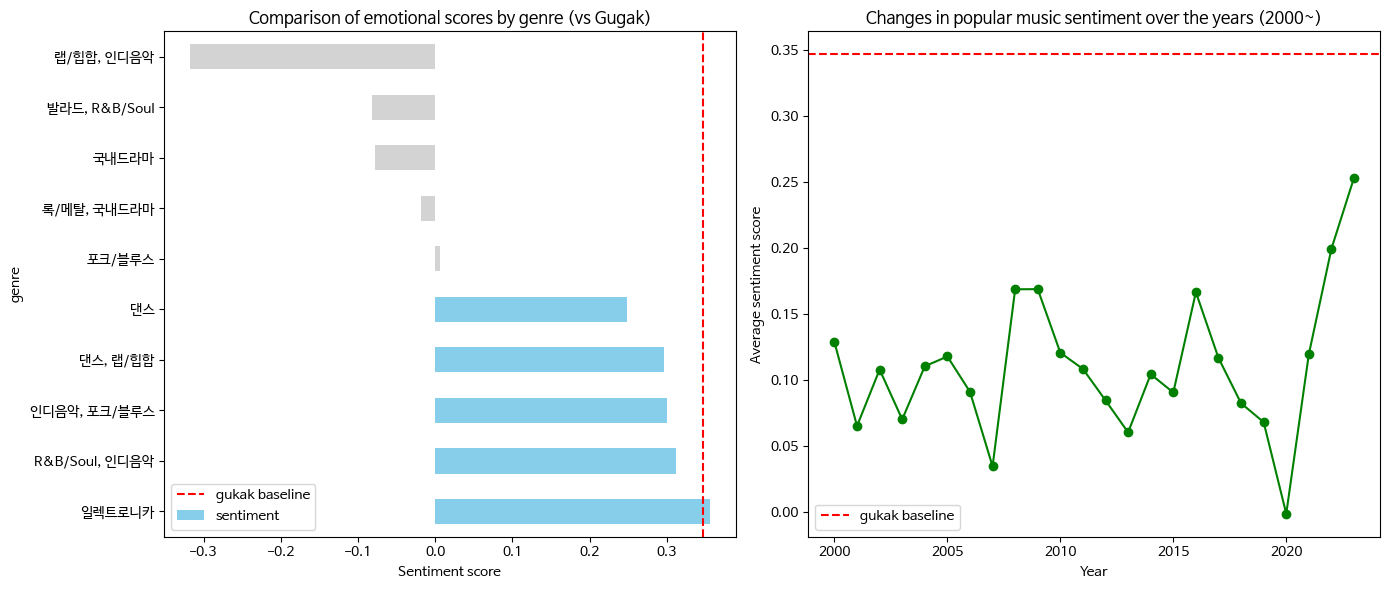

In [12]:
# [2] Data load function (automatic encoding detection)
def load_csv_robust(filename):
    if not os.path.exists(filename): return None
    encodings = ['utf-8', 'cp949', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(filename, encoding=enc)
        except: continue
    return None


melon_df = load_csv_robust('final_melon_chart_analysis.csv')
gugak_df = load_csv_robust('국악_통합데이터_10개압축분.csv')

with open('SentiWord_info.json', 'r', encoding='utf-8') as f:
    senti_data = json.load(f)

# [3] Calculating emotional scores based on traditional Korean music (reflecting skill weighting)
senti_dict = {entry['word']: int(entry['polarity']) for entry in senti_data}

def calc_sentiment(text):
    if not isinstance(text, str): return None
    text = text.replace('\n', ' ')
    tokens = text.split()
    score_sum = 0
    match_count = 0
    for token in tokens:
        if token in senti_dict:
            score_sum += senti_dict[token]
            match_count += 1
            continue
        clean_token = re.sub(r'[^\w]', '', token)
        if clean_token and clean_token in senti_dict:
            score_sum += senti_dict[clean_token]
            match_count += 1
    return score_sum / match_count if match_count > 0 else None

# Korean traditional music data processing
gugak_lyrics = gugak_df[gugak_df['lyrics'].notna()].copy()
gugak_lyrics['sentiment'] = gugak_lyrics['lyrics'].apply(calc_sentiment)
gugak_valid = gugak_lyrics.dropna(subset=['sentiment', 'Soul Score'])

# Weighted average calculation (higher Soul Score is given more weight)
if gugak_valid['Soul Score'].sum() == 0:
    gugak_ref_score = gugak_valid['sentiment'].mean()
else:
    gugak_ref_score = np.average(gugak_valid['sentiment'], weights=gugak_valid['Soul Score'])

print(f"🇰🇷 sentiment score based on gukak: {gugak_ref_score:.4f}")

# [4] Melon data processing
# If the file contains a calculated score, use it; if not, calculate it.
if 'Combined_Avg_Polarity' in melon_df.columns:
    melon_df['sentiment'] = pd.to_numeric(melon_df['Combined_Avg_Polarity'], errors='coerce')
else:
    print("   (Calculating Melon emotional score...)")
    melon_df['sentiment'] = melon_df['lyrics'].apply(calc_sentiment)

melon_valid = melon_df.dropna(subset=['sentiment'])

# --- Analysis 1: Ranking of Korean Traditional Music Similarities by Genre ---
# Excluding genres with too few songs (only genres with 50 or more songs)
genre_counts = melon_valid['genre'].value_counts()
major_genres = genre_counts[genre_counts > 50].index

# Calculating average sentiment by genre
genre_sentiment = melon_valid[melon_valid['genre'].isin(major_genres)].groupby('genre')['sentiment'].mean()

# Calculating the difference from the national music score (absolute value)
genre_diff = (genre_sentiment - gugak_ref_score).abs().sort_values()

print("\n [Result 1] Top 5 genres most similar to Korean traditional music")
print(genre_diff.head(5))

print("\n [Result 2] Top 5 genres most distant from Korean traditional music sensibility")
print(genre_diff.tail(5))

# --- Analysis 2: Trends in Korean Traditional Music Emotions by Year ---
year_sentiment = melon_valid.groupby('year')['sentiment'].mean()

# --- EDA ---
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)

top_genres = genre_sentiment[genre_diff.head(5).index]
bottom_genres = genre_sentiment[genre_diff.tail(5).index]
plot_genres = pd.concat([top_genres, bottom_genres])

colors = ['skyblue' if x in top_genres.index else 'lightgray' for x in plot_genres.index]
plot_genres.plot(kind='barh', color=colors)
plt.axvline(gugak_ref_score, color='red', linestyle='dashed', label='gukak baseline')
plt.title('Comparison of emotional scores by genre (vs Gugak)')
plt.xlabel('Sentiment score')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(year_sentiment.index, year_sentiment.values, marker='o', linestyle='-', color='green')
plt.axhline(gugak_ref_score, color='red', linestyle='dashed', label='gukak baseline')
plt.title('Changes in popular music sentiment over the years (2000~)')
plt.xlabel('Year')
plt.ylabel('Average sentiment score')
plt.legend()

plt.tight_layout()
plt.show()